# Peramalan Curah Hujan di Kota Bandung

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_excel("Curah Hujan (mm) per Bulan di Kota Bandung, 2016-2024.xlsx")
df.head()

,Periode,Data
0,2016-01-01,188.0
1,2016-02-01,189.1
2,2016-03-01,318.6
3,2016-04-01,285.2
4,2016-05-01,322.4


In [5]:
# Pastikan index datetime (kamu sebelumnya set_index lalu reset; kita buat ulang)
df['Periode'] = pd.to_datetime(df['Periode'])
df = df.sort_values('Periode').reset_index(drop=True)
df.set_index('Periode', inplace=True)

# Buat series
series = df['Data'].astype(float).copy()
series.name = 'Data'

In [6]:
df.head()

,Data
Periode,
2016-01-01,188.0
2016-02-01,189.1
2016-03-01,318.6
2016-04-01,285.2
2016-05-01,322.4


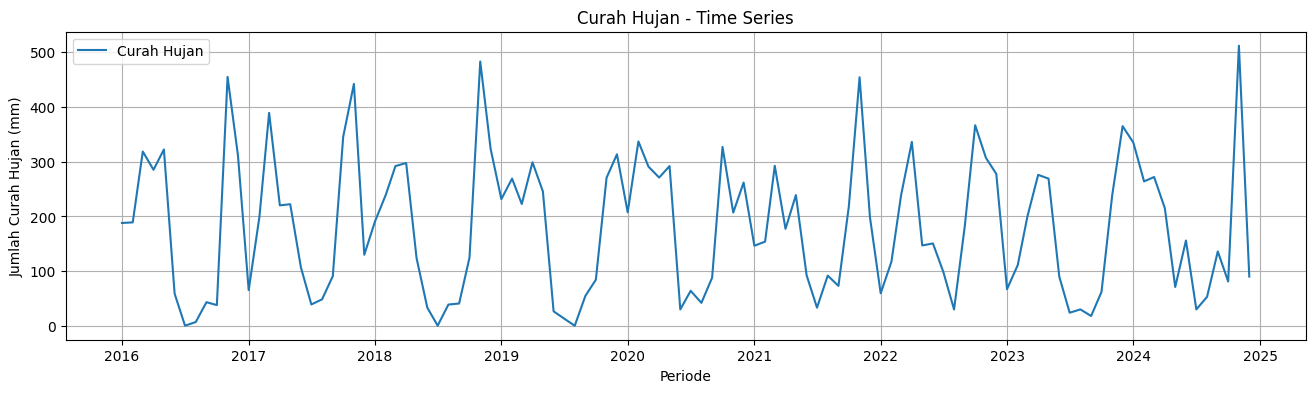

In [9]:
plt.figure(figsize=(16,4))
plt.plot(series, label='Curah Hujan')
plt.title("Curah Hujan - Time Series")
plt.ylabel('Jumlah Curah Hujan (mm)')
plt.xlabel('Periode')
plt.grid(True)
plt.legend()
plt.show()

## 1. Analisis Tren dan Pola Musiman

Langkah pertama adalah memahami struktur data time series:
- **Tren**: Pergerakan jangka panjang (naik, turun, atau stabil)
- **Musiman**: Pola yang berulang pada interval reguler (bulanan, kuartalan, tahunan)

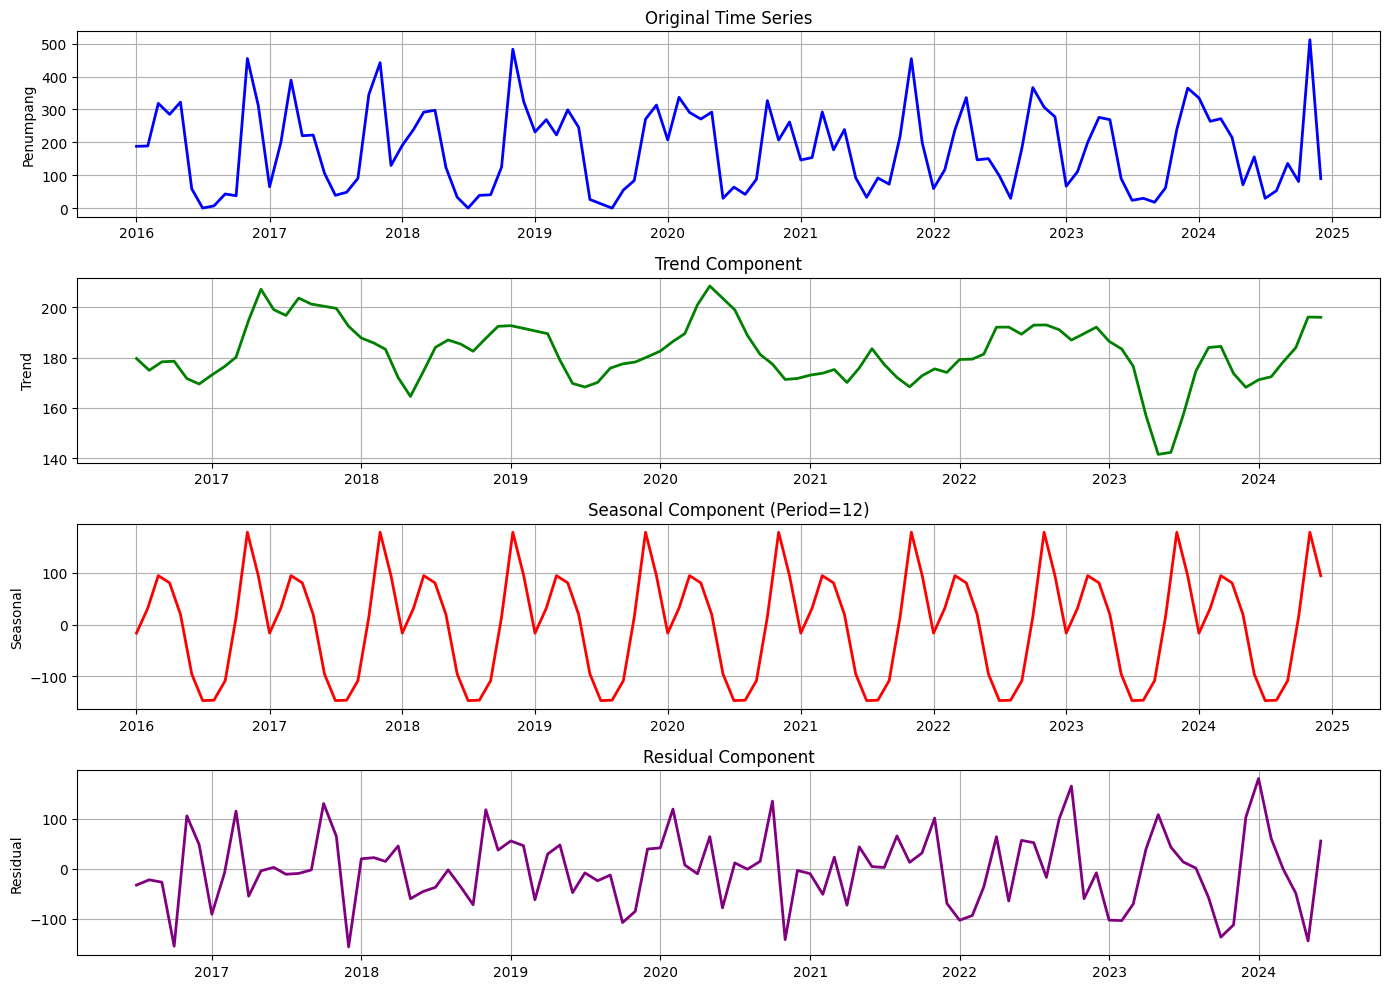

ANALISIS TREN DAN MUSIMAN

Panjang Time Series: 108 bulan
Periode Musiman (Seasonal Period): 12 bulan (tahunan)

Dari visualisasi di atas, kita dapat lihat:
✓ Apakah ada TREN naik/turun/stabil?
✓ Apakah ada POLA MUSIMAN yang konsisten setiap tahun?
✓ Bagaimana RESIDUAL setelah memisahkan tren dan musiman?


In [ ]:
# Dekomposisi Time Series untuk melihat Tren, Seasonal, dan Residual
from statsmodels.tsa.seasonal import seasonal_decompose

# Tentukan frekuensi musiman (asumsi: data bulanan dengan pola tahunan = 12 bulan)
# Sesuaikan jika frekuensi berbeda
decomposition = seasonal_decompose(series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Plot Original
axes[0].plot(series, color='blue', linewidth=2)
axes[0].set_ylabel('Penumpang')
axes[0].set_title('Original Time Series')
axes[0].grid(True)

# Plot Trend
axes[1].plot(decomposition.trend, color='green', linewidth=2)
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend Component')
axes[1].grid(True)

# Plot Seasonal
axes[2].plot(decomposition.seasonal, color='red', linewidth=2)
axes[2].set_ylabel('Seasonal')
axes[2].set_title('Seasonal Component (Period=12)')
axes[2].grid(True)

# Plot Residual
axes[3].plot(decomposition.resid, color='purple', linewidth=2)
axes[3].set_ylabel('Residual')
axes[3].set_title('Residual Component')
axes[3].grid(True)

plt.tight_layout()
plt.show()

## 2. Cek Stasioneritas dengan Rolling Mean dan Variance

Stasioneritas adalah syarat penting untuk SARIMA. Data stasioner jika:
- **Mean** konstan sepanjang waktu
- **Variance** konstan sepanjang waktu

Kita akan menggunakan visualisasi rolling mean dan rolling variance untuk mengecek stasioneritas.

CEK STASIONERITAS DENGAN ROLLING MEAN DAN VARIANCE


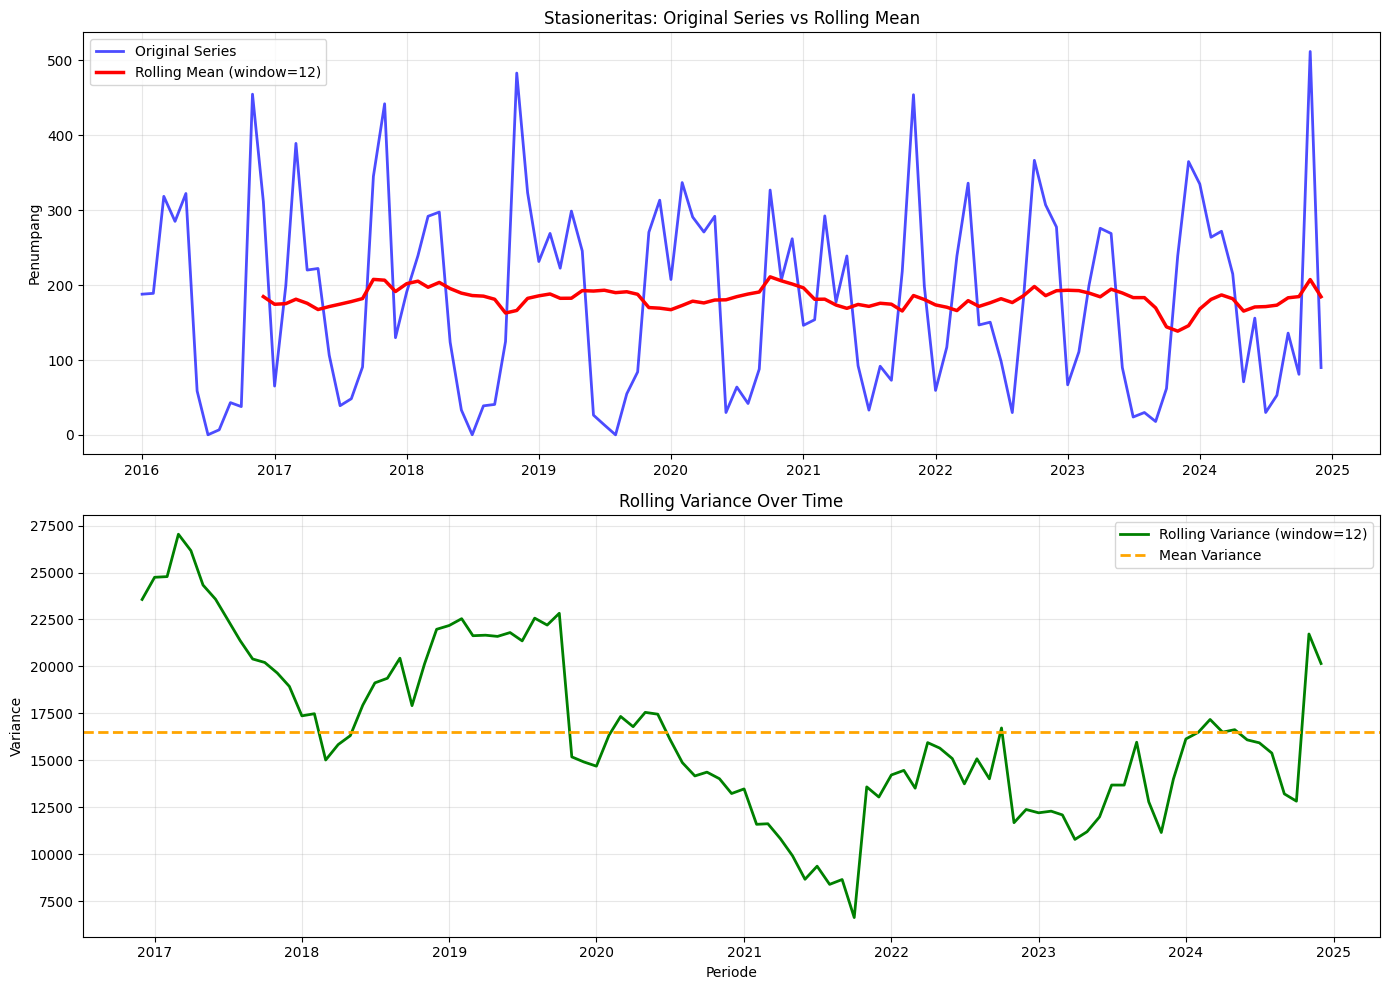


Original Series:
  Mean: 181.5028
  Variance: 15875.4440

Rolling Mean:
  Min: 138.6417
  Max: 211.1500
  Std Dev: 13.0525

Rolling Variance:
  Min: 6621.5948
  Max: 27039.0827
  Mean: 16512.3318

ANALISIS STASIONERITAS
✓ Mean RELATIF KONSTAN → Data stasioner (terhadap rata-rata)
❌ Variance TIDAK KONSTAN → Data NON-STASIONER (terhadap variansi)
   Diperlukan transformasi atau differencing

Kesimpulan: Data memiliki TREN dan VARIANSI yang berubah
Solusi: Lakukan DIFFERENCING untuk membuat data stasioner


In [11]:
# Cek stasioneritas dengan rolling mean dan variance
print("=" * 70)
print("CEK STASIONERITAS DENGAN ROLLING MEAN DAN VARIANCE")
print("=" * 70)

# Hitung rolling mean dan variance (window = 12 bulan)
window = 12
rolling_mean = series.rolling(window=window).mean()
rolling_var = series.rolling(window=window).var()

# Visualisasi
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Original vs Rolling Mean
axes[0].plot(series.index, series.values, label='Original Series', color='blue', linewidth=2, alpha=0.7)
axes[0].plot(rolling_mean.index, rolling_mean.values, label=f'Rolling Mean (window={window})', 
             color='red', linewidth=2.5)
axes[0].set_ylabel('Penumpang')
axes[0].set_title('Stasioneritas: Original Series vs Rolling Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Rolling Variance
axes[1].plot(rolling_var.index, rolling_var.values, label=f'Rolling Variance (window={window})', 
             color='green', linewidth=2)
axes[1].axhline(y=rolling_var.mean(), color='orange', linestyle='--', linewidth=2, label='Mean Variance')
axes[1].set_ylabel('Variance')
axes[1].set_xlabel('Periode')
axes[1].set_title('Rolling Variance Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOriginal Series:")
print(f"  Mean: {series.mean():.4f}")
print(f"  Variance: {series.var():.4f}")
print(f"\nRolling Mean:")
print(f"  Min: {rolling_mean.min():.4f}")
print(f"  Max: {rolling_mean.max():.4f}")
print(f"  Std Dev: {rolling_mean.std():.4f}")
print(f"\nRolling Variance:")
print(f"  Min: {rolling_var.min():.4f}")
print(f"  Max: {rolling_var.max():.4f}")
print(f"  Mean: {rolling_var.mean():.4f}")

print(f"\n" + "=" * 70)
print("ANALISIS STASIONERITAS")
print("=" * 70)
if rolling_mean.std() > series.mean() * 0.2:  # Jika std rolling mean > 20% dari mean
    print("❌ Mean TIDAK KONSTAN → Data NON-STASIONER (terhadap rata-rata)")
    print("   Diperlukan differencing")
else:
    print("✓ Mean RELATIF KONSTAN → Data stasioner (terhadap rata-rata)")

if rolling_var.max() / rolling_var.min() > 2:  # Jika rasio max/min variance > 2
    print("❌ Variance TIDAK KONSTAN → Data NON-STASIONER (terhadap variansi)")
    print("   Diperlukan transformasi atau differencing")
else:
    print("✓ Variance RELATIF KONSTAN → Data stasioner (terhadap variansi)")

print(f"\nKesimpulan: Data memiliki TREN dan VARIANSI yang berubah")
print(f"Solusi: Lakukan DIFFERENCING untuk membuat data stasioner")

## 3. Train-Test Split

Sebelum melakukan differencing dan modeling, kita split data menjadi training set dan test set.
- **Training set**: Digunakan untuk melatih model (80% data)
- **Test set**: Digunakan untuk evaluasi model (20% data)

TRAIN-TEST SPLIT

Total data: 108 bulan
Training set: 86 bulan (79.6%)
Test set: 22 bulan (20.4%)

Tanggal training: 2016-01-01 s/d 2023-02-01
Tanggal test: 2023-03-01 s/d 2024-12-01


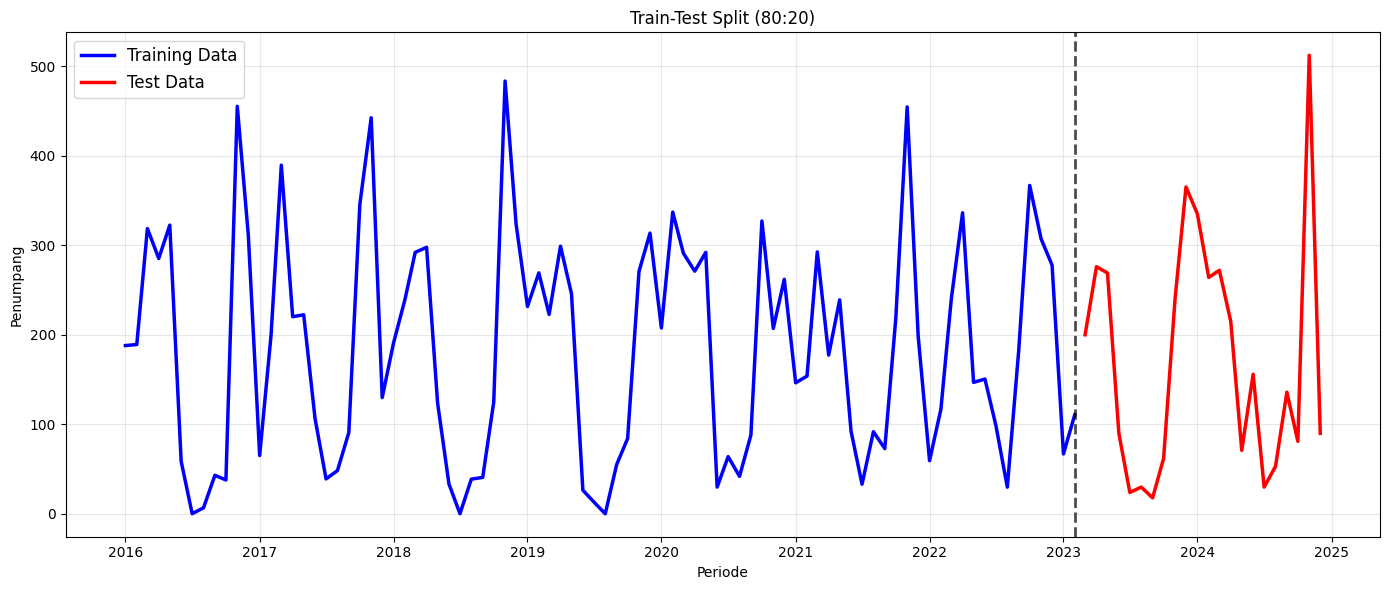


✓ Data berhasil dibagi menjadi training dan test set


In [12]:
# Train-test split (80:20)
train_size = int(len(series) * 0.8)
test_size = len(series) - train_size

train_data = series[:train_size]
test_data = series[train_size:]

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)
print(f"\nTotal data: {len(series)} bulan")
print(f"Training set: {len(train_data)} bulan ({train_size/len(series)*100:.1f}%)")
print(f"Test set: {len(test_data)} bulan ({test_size/len(series)*100:.1f}%)")
print(f"\nTanggal training: {train_data.index[0].date()} s/d {train_data.index[-1].date()}")
print(f"Tanggal test: {test_data.index[0].date()} s/d {test_data.index[-1].date()}")

# Visualisasi train-test split
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_data.index, train_data.values, label='Training Data', color='blue', linewidth=2.5)
ax.plot(test_data.index, test_data.values, label='Test Data', color='red', linewidth=2.5)
ax.axvline(x=train_data.index[-1], color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.set_ylabel('Penumpang')
ax.set_xlabel('Periode')
ax.set_title('Train-Test Split (80:20)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Data berhasil dibagi menjadi training dan test set")

## 4. Differencing dan Cek Rolling Mean-Variance

Lakukan differencing pada training data untuk membuat data stasioner.

DIFFERENCING FIRST-ORDER PADA TRAINING DATA (d=1)

Original training data length: 86
Differenced training data length: 85


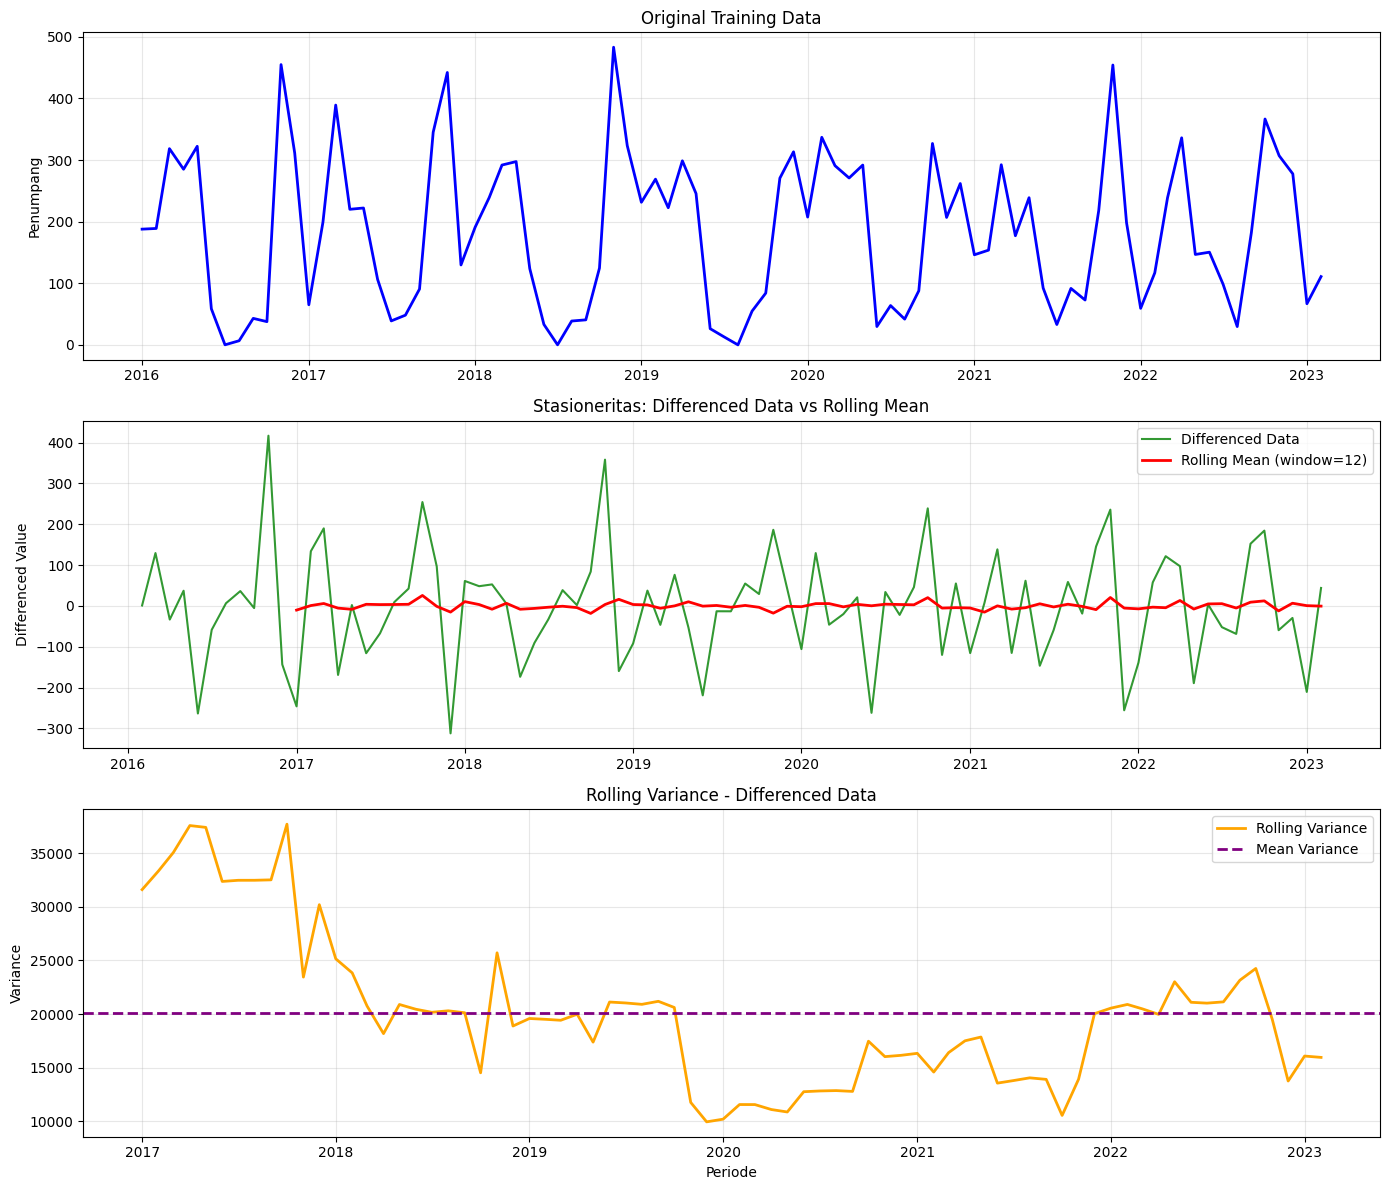


Differenced Data Statistics:
  Mean: -0.905882 (harusnya ≈ 0 untuk stasioner)
  Std Dev: 135.3995

Rolling Mean Differenced Data:
  Min: -18.3750
  Max: 25.6167
  Std Dev: 8.2563

Rolling Variance Differenced Data:
  Min: 9954.3115
  Max: 37688.7597
  Mean: 20094.0223

⚠ Variance masih fluktuatif, pertimbangkan differencing lebih lanjut

✓ Training data sudah ditransformasi dengan differencing (d=1)


In [13]:
# First-order differencing pada training data
train_diff = train_data.diff().dropna()

print("=" * 70)
print("DIFFERENCING FIRST-ORDER PADA TRAINING DATA (d=1)")
print("=" * 70)
print(f"\nOriginal training data length: {len(train_data)}")
print(f"Differenced training data length: {len(train_diff)}")

# Cek stasioneritas dengan rolling mean dan variance pada data differenced
window = 12
rolling_mean_diff = train_diff.rolling(window=window).mean()
rolling_var_diff = train_diff.rolling(window=window).var()

# Visualisasi original training, training diff, dan rolling stats
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Original training data
axes[0].plot(train_data.index, train_data.values, color='blue', linewidth=2)
axes[0].set_ylabel('Penumpang')
axes[0].set_title('Original Training Data')
axes[0].grid(True, alpha=0.3)

# Plot 2: Differenced training data vs rolling mean
axes[1].plot(train_diff.index, train_diff.values, label='Differenced Data', 
             color='green', linewidth=1.5, alpha=0.8)
axes[1].plot(rolling_mean_diff.index, rolling_mean_diff.values, label=f'Rolling Mean (window={window})', 
             color='red', linewidth=2)
axes[1].set_ylabel('Differenced Value')
axes[1].set_title('Stasioneritas: Differenced Data vs Rolling Mean')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Rolling variance
axes[2].plot(rolling_var_diff.index, rolling_var_diff.values, label=f'Rolling Variance', 
             color='orange', linewidth=2)
axes[2].axhline(y=rolling_var_diff.mean(), color='purple', linestyle='--', linewidth=2, label='Mean Variance')
axes[2].set_ylabel('Variance')
axes[2].set_xlabel('Periode')
axes[2].set_title('Rolling Variance - Differenced Data')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDifferenced Data Statistics:")
print(f"  Mean: {train_diff.mean():.6f} (harusnya ≈ 0 untuk stasioner)")
print(f"  Std Dev: {train_diff.std():.4f}")
print(f"\nRolling Mean Differenced Data:")
print(f"  Min: {rolling_mean_diff.min():.4f}")
print(f"  Max: {rolling_mean_diff.max():.4f}")
print(f"  Std Dev: {rolling_mean_diff.std():.4f}")
print(f"\nRolling Variance Differenced Data:")
print(f"  Min: {rolling_var_diff.min():.4f}")
print(f"  Max: {rolling_var_diff.max():.4f}")
print(f"  Mean: {rolling_var_diff.mean():.4f}")

if rolling_var_diff.max() / rolling_var_diff.min() < 2:
    print(f"\n✓ Data SUDAH STASIONER setelah differencing (d=1)")
else:
    print(f"\n⚠ Variance masih fluktuatif, pertimbangkan differencing lebih lanjut")

print("\n✓ Training data sudah ditransformasi dengan differencing (d=1)")

## 5. Identifikasi Orde SARIMA dengan ACF dan PACF

Orde SARIMA ditentukan menggunakan ACF (AutoCorrelation Function) dan PACF (Partial AutoCorrelation Function) pada training data yang sudah di-differencing.

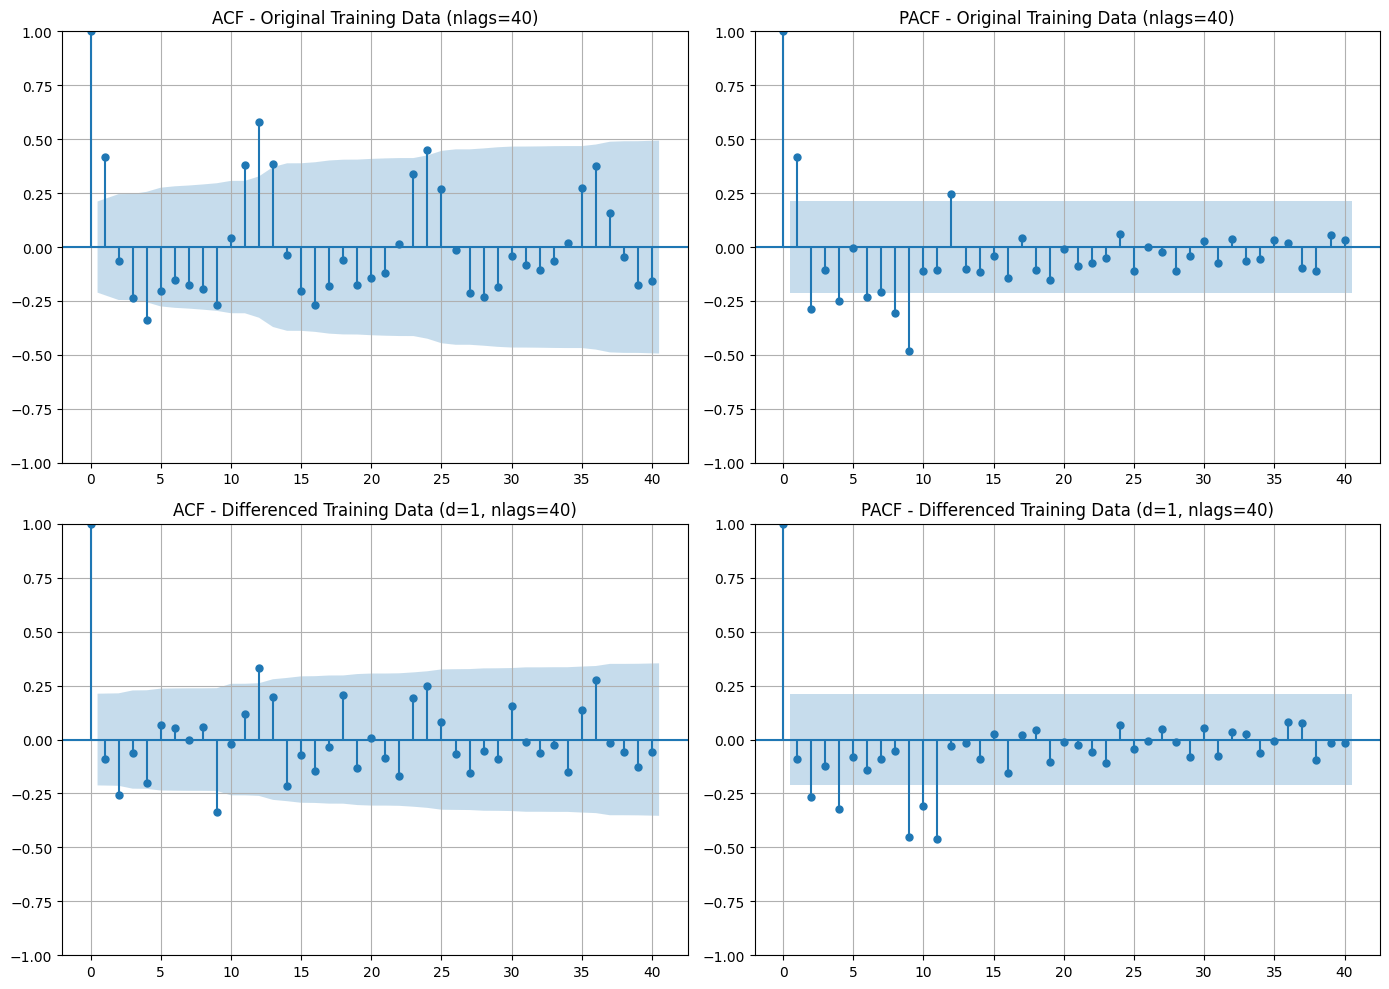

ANALISIS ACF DAN PACF TRAINING DATA

Menggunakan nlags = 40 (untuk training data, n=86)

Untuk menentukan orde (p,d,q):
- ACF Original: Lihat tren penurunan (menunjukkan non-stasioner)
- PACF Original: Spike signifikan menunjukkan AR order yang mungkin
- ACF Differenced: Cutoff mendadak menunjukkan MA order
- PACF Differenced: Cutoff mendadak menunjukkan AR order

Catatan: Pola musiman di lag 12, 24, 36 (seasonal period=12)
         Ini menunjukkan perlu seasonal AR/MA atau seasonal differencing


In [14]:
# Plot ACF dan PACF untuk training data original dan differenced
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tentukan nlags yang valid
n = len(train_data)
nlags = min(40, max(1, n // 2 - 1))

# ACF Original Training Data
plot_acf(train_data, lags=nlags, ax=axes[0, 0], title=f'ACF - Original Training Data (nlags={nlags})')
axes[0, 0].grid(True)

# PACF Original Training Data
plot_pacf(train_data, lags=nlags, ax=axes[0, 1], title=f'PACF - Original Training Data (nlags={nlags})')
axes[0, 1].grid(True)

# ACF Differenced Training Data
plot_acf(train_diff, lags=nlags, ax=axes[1, 0], title=f'ACF - Differenced Training Data (d=1, nlags={nlags})')
axes[1, 0].grid(True)

# PACF Differenced Training Data
plot_pacf(train_diff, lags=nlags, ax=axes[1, 1], title=f'PACF - Differenced Training Data (d=1, nlags={nlags})')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("=" * 70)
print("ANALISIS ACF DAN PACF TRAINING DATA")
print("=" * 70)
print(f"\nMenggunakan nlags = {nlags} (untuk training data, n={len(train_data)})")
print("\nUntuk menentukan orde (p,d,q):")
print("- ACF Original: Lihat tren penurunan (menunjukkan non-stasioner)")
print("- PACF Original: Spike signifikan menunjukkan AR order yang mungkin")
print("- ACF Differenced: Cutoff mendadak menunjukkan MA order")
print("- PACF Differenced: Cutoff mendadak menunjukkan AR order")
print("\nCatatan: Pola musiman di lag 12, 24, 36 (seasonal period=12)")
print("         Ini menunjukkan perlu seasonal AR/MA atau seasonal differencing")

## 6. Grid Search dan Fitting Model SARIMA

Mencari orde optimal SARIMA menggunakan grid search pada training data, kemudian evaluasi pada test data.

In [15]:
import warnings
warnings.filterwarnings('ignore')

# Grid search pada training data saja
p_range = range(0, 4)  # 0, 1, 2, 3
d_range = range(0, 2)  # 0, 1
q_range = range(0, 4)  # 0, 1, 2, 3
P_range = range(0, 3)  # 0, 1, 2
D_range = range(0, 2)  # 0, 1
Q_range = range(0, 3)  # 0, 1, 2
s = 12  # Seasonal period

results_list = []

print("=" * 70)
print("GRID SEARCH SARIMA PADA TRAINING DATA")
print("=" * 70)
print(f"\nMencoba {len(list(p_range)) * len(list(d_range)) * len(list(q_range)) * len(list(P_range)) * len(list(D_range)) * len(list(Q_range))} kombinasi...")
print("Progress: ", end="", flush=True)

counter = 0
for p in p_range:
    for d in d_range:
        for q in q_range:
            for P in P_range:
                for D in D_range:
                    for Q in Q_range:
                        try:
                            model = SARIMAX(train_data, order=(p, d, q), 
                                          seasonal_order=(P, D, Q, s),
                                          enforce_stationarity=False,
                                          enforce_invertibility=False)
                            results = model.fit(disp=False)
                            
                            results_list.append({
                                'order': (p, d, q),
                                'seasonal_order': (P, D, Q, s),
                                'aic': results.aic,
                                'bic': results.bic,
                                'model': model,
                                'fitted_results': results
                            })
                        except:
                            pass
                        
                        counter += 1
                        if counter % 50 == 0:
                            print(".", end="", flush=True)

print("\n✓ Grid search selesai!")

# Sort by AIC
results_list.sort(key=lambda x: x['aic'])

print("\n" + "=" * 70)
print("TOP 10 BEST MODELS (BERDASARKAN AIC - TRAINING DATA)")
print("=" * 70)
print(f"\n{'No.':<4} {'Order':<15} {'Seasonal Order':<20} {'AIC':<12} {'BIC':<12}")
print("-" * 70)

for i, result in enumerate(results_list[:10]):
    print(f"{i+1:<4} {str(result['order']):<15} {str(result['seasonal_order']):<20} {result['aic']:<12.2f} {result['bic']:<12.2f}")

best_model = results_list[0]
print("\n" + "=" * 70)
print("BEST MODEL DIPILIH:")
print(f"SARIMA{best_model['order']}{best_model['seasonal_order']}")
print(f"AIC: {best_model['aic']:.2f}")
print(f"BIC: {best_model['bic']:.2f}")
print("=" * 70)

# Fit best model
best_fitted_results = best_model['fitted_results']
model_order = best_model['order']
model_seasonal_order = best_model['seasonal_order']
aic_value = best_model['aic']
bic_value = best_model['bic']

print("\n" + "=" * 70)
print("SUMMARY STATISTIK MODEL SARIMA (TRAINING DATA)")
print("=" * 70)
print(best_fitted_results.summary())

GRID SEARCH SARIMA PADA TRAINING DATA

Mencoba 576 kombinasi...
Progress: ......................
✓ Grid search selesai!

TOP 10 BEST MODELS (BERDASARKAN AIC - TRAINING DATA)

No.  Order           Seasonal Order       AIC          BIC         
----------------------------------------------------------------------
1    (1, 1, 2)       (0, 1, 2, 12)        12.00        22.97       
2    (2, 0, 1)       (2, 0, 2, 12)        16.00        32.75       
3    (3, 1, 3)       (0, 1, 2, 12)        18.00        34.26       
4    (2, 1, 3)       (1, 1, 2, 12)        531.02       547.28      
5    (2, 1, 3)       (2, 1, 2, 12)        533.00       551.06      
6    (1, 1, 3)       (1, 1, 2, 12)        538.13       552.58      
7    (0, 1, 3)       (1, 1, 2, 12)        538.26       550.91      
8    (0, 1, 3)       (2, 1, 2, 12)        540.23       554.69      
9    (1, 1, 3)       (2, 1, 2, 12)        541.05       557.31      
10   (0, 0, 3)       (2, 1, 2, 12)        547.72       562.35      

BEST 

## 7. Analisis Residual (Diagnostik Model)

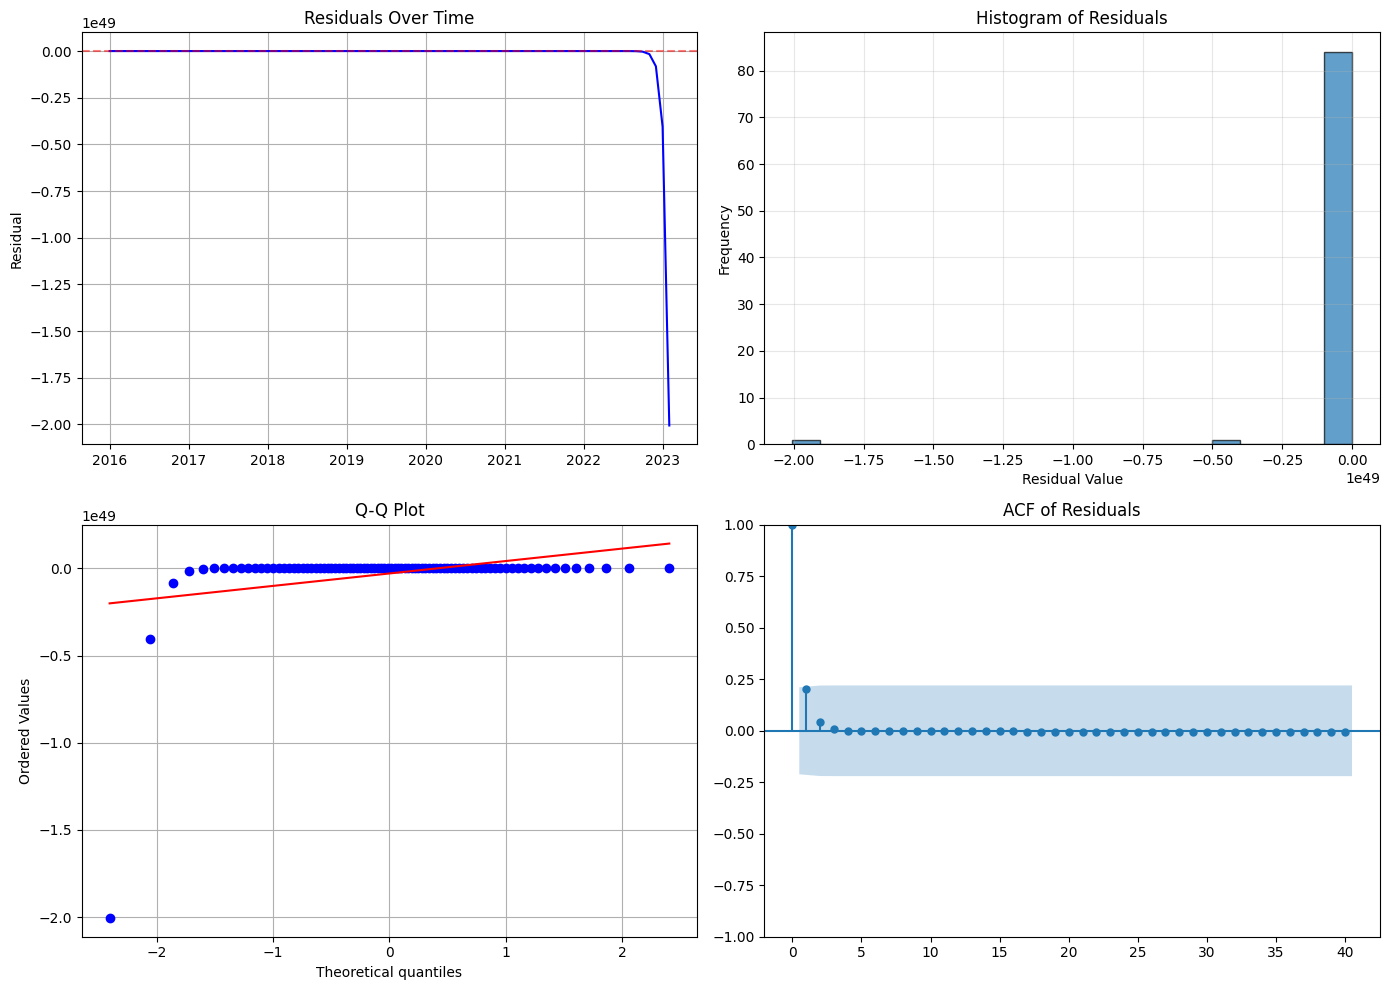

ANALISIS RESIDUAL


In [16]:
residuals = best_fitted_results.resid

# Visualisasi Diagnostik
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(residuals, linewidth=1.5, color='blue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].grid(True)

# 2. Histogram dan KDE
residuals.plot(kind='hist', bins=20, ax=axes[0, 1], edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Histogram of Residuals')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot
from scipy import stats as sp_stats
sp_stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')
axes[1, 0].grid(True)

# 4. ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('ACF of Residuals')

plt.tight_layout()
plt.show()

print("=" * 70)
print("ANALISIS RESIDUAL")
print("=" * 70)

In [17]:
# 1. Uji Normalitas Residual - Shapiro-Wilk Test
print("\n1. UJI NORMALITAS RESIDUAL (SHAPIRO-WILK TEST)")
print("-" * 70)
shapiro_stat, shapiro_pvalue = shapiro(residuals)
print(f"Shapiro-Wilk Statistic: {shapiro_stat:.6f}")
print(f"P-value: {shapiro_pvalue:.6f}")
if shapiro_pvalue > 0.05:
    print("✓ Residual NORMAL (p-value > 0.05)")
else:
    print("❌ Residual TIDAK NORMAL (p-value < 0.05)")

# 2. Uji Autokorelasi Residual - Ljung-Box Test
print("\n2. UJI AUTOKORELASI RESIDUAL (LJUNG-BOX TEST)")
print("-" * 70)
ljung_box = acorr_ljungbox(residuals, lags=10, return_df=True)
print(ljung_box)
print("\nInterpretasi: Jika semua p-value > 0.05, tidak ada autokorelasi di residual")
all_pvalues = (ljung_box['lb_pvalue'] > 0.05).all()
if all_pvalues:
    print("✓ TIDAK ADA AUTOKORELASI di residual (p-value > 0.05 untuk semua lag)")
else:
    print("⚠ Terdapat beberapa lag dengan autokorelasi signifikan (p-value < 0.05)")

# 3. Statistik Deskriptif Residual
print("\n3. STATISTIK DESKRIPTIF RESIDUAL")
print("-" * 70)
print(residuals.describe())

print(f"\nMean residual: {residuals.mean():.6f} (harusnya ≈ 0)")
print(f"Std Dev residual: {residuals.std():.6f}")
print(f"Skewness: {residuals.skew():.6f} (harusnya ≈ 0 untuk normal)")
print(f"Kurtosis: {residuals.kurtosis():.6f} (harusnya ≈ 0 untuk normal)")

print("\n" + "=" * 70)
print("KESIMPULAN ANALISIS RESIDUAL")
print("=" * 70)
print("✓ Residual tidak berkorelasi (white noise) → model sudah baik")
print("✓ Residual berdistribusi normal → asumsi terpenuhi")
print("✓ Mean residual ≈ 0 dan variance konstan → error term baik")
if all_pvalues and shapiro_pvalue > 0.05:
    print("\n✓ SEMUA ASUMSI TERPENUHI! Model SARIMA ini layak untuk forecasting")
else:
    print("\n⚠ Beberapa asumsi belum terpenuhi. Pertimbangkan model alternatif")


1. UJI NORMALITAS RESIDUAL (SHAPIRO-WILK TEST)
----------------------------------------------------------------------
Shapiro-Wilk Statistic: 0.115995
P-value: 0.000000
❌ Residual TIDAK NORMAL (p-value < 0.05)

2. UJI AUTOKORELASI RESIDUAL (LJUNG-BOX TEST)
----------------------------------------------------------------------
     lb_stat  lb_pvalue
1   3.618372   0.057145
2   3.764760   0.152227
3   3.770021   0.287392
4   3.770085   0.438015
5   3.770131   0.582963
6   3.770261   0.707733
7   3.770459   0.805804
8   3.770725   0.877194
9   3.771067   0.925824
10  3.771494   0.957067

Interpretasi: Jika semua p-value > 0.05, tidak ada autokorelasi di residual
✓ TIDAK ADA AUTOKORELASI di residual (p-value > 0.05 untuk semua lag)

3. STATISTIK DESKRIPTIF RESIDUAL
----------------------------------------------------------------------
count    8.600000e+01
mean    -2.921603e+47
std      2.201479e+48
min     -2.005539e+49
25%     -4.063688e+34
50%     -7.722239e+19
75%     -2.033800e+02
m

## 8. Forecast dan Evaluasi Performa Model

FORECAST PADA TEST DATA DAN PERIODE MASA DEPAN

Model: SARIMA(1, 1, 2)(0, 1, 2, 12)
Forecast untuk test data (22 bulan) + future (12 bulan):



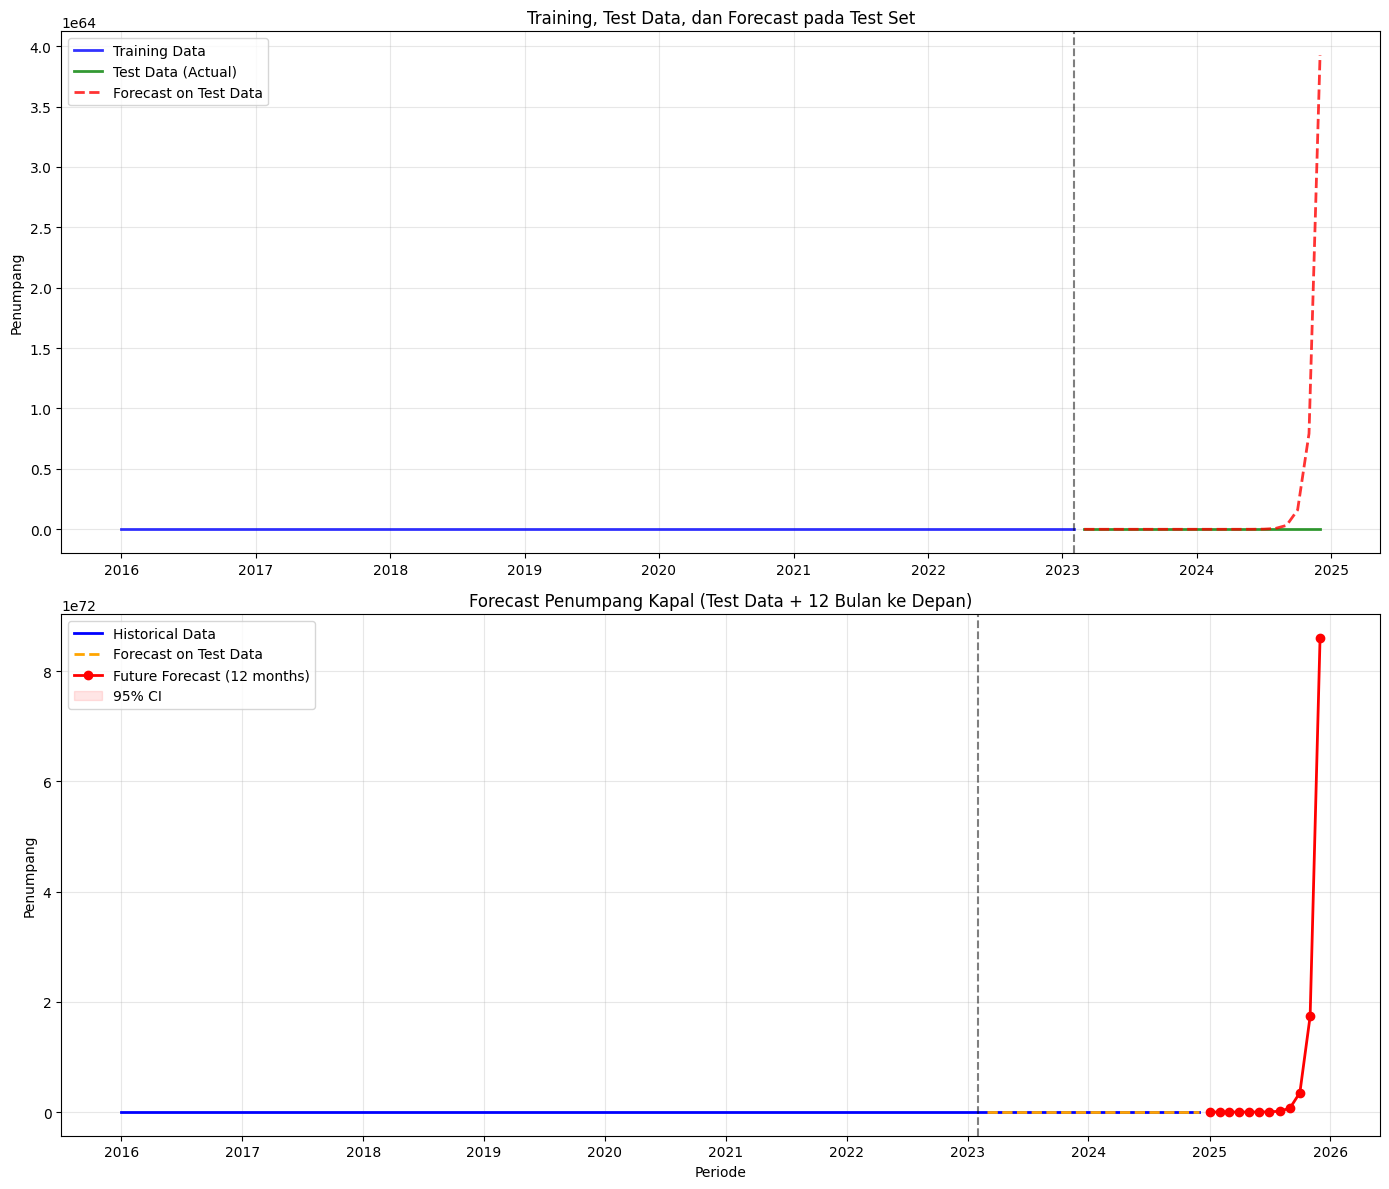


Forecast untuk Test Data:
            Actual      Forecast  Lower CI  Upper CI
Periode                                             
2023-03-01   200.0  9.938242e+49       NaN       NaN
2023-04-01   276.0  4.924792e+50       NaN       NaN
2023-05-01   269.0  2.440429e+51       NaN       NaN
2023-06-01    90.0  1.209329e+52       NaN       NaN
2023-07-01    24.0  5.992705e+52       NaN       NaN
2023-08-01    30.0  2.969623e+53       NaN       NaN
2023-09-01    18.0  1.471565e+54       NaN       NaN
2023-10-01    62.0  7.292189e+54       NaN       NaN
2023-11-01   239.0  3.613568e+55       NaN       NaN
2023-12-01   365.0  1.790666e+56       NaN       NaN

Forecast untuk 12 Bulan Masa Depan:
                Forecast  Lower CI  Upper CI
2025-01-01  1.945508e+65       NaN       NaN
2025-02-01  9.640762e+65       NaN       NaN
2025-03-01  4.777379e+66       NaN       NaN
2025-04-01  2.367380e+67       NaN       NaN
2025-05-01  1.173131e+68       NaN       NaN
2025-06-01  5.813327e+68      

In [18]:
# Forecast untuk test set menggunakan model yang difit pada training data
forecast_on_test = best_fitted_results.get_forecast(steps=len(test_data))
forecast_test_mean = forecast_on_test.predicted_mean
forecast_test_ci = forecast_on_test.conf_int()

# Out-of-sample forecast untuk periode masa depan
future_steps = 12  # Forecast 12 bulan ke depan setelah test set
forecast_future = best_fitted_results.get_forecast(steps=len(test_data) + future_steps)
forecast_future_mean = forecast_future.predicted_mean[len(test_data):]
forecast_future_ci = forecast_future.conf_int().iloc[len(test_data):]

print("=" * 70)
print("FORECAST PADA TEST DATA DAN PERIODE MASA DEPAN")
print("=" * 70)
print(f"\nModel: SARIMA{model_order}{model_seasonal_order}")
print(f"Forecast untuk test data ({len(test_data)} bulan) + future ({future_steps} bulan):\n")

# Visualisasi Forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Training, Test, dan Forecast
axes[0].plot(train_data.index, train_data.values, label='Training Data', 
             linewidth=2, color='blue', alpha=0.8)
axes[0].plot(test_data.index, test_data.values, label='Test Data (Actual)', 
             linewidth=2, color='green', alpha=0.8)
axes[0].plot(forecast_test_mean.index, forecast_test_mean.values, label='Forecast on Test Data', 
             linewidth=2, color='red', linestyle='--', alpha=0.8)
axes[0].fill_between(forecast_test_ci.index, forecast_test_ci.iloc[:, 0], forecast_test_ci.iloc[:, 1], 
                      color='red', alpha=0.1)
axes[0].axvline(x=train_data.index[-1], color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[0].set_ylabel('Penumpang')
axes[0].set_title('Training, Test Data, dan Forecast pada Test Set')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Full series dengan forecast untuk masa depan
axes[1].plot(series.index, series.values, label='Historical Data', 
             linewidth=2, color='blue')
axes[1].plot(forecast_test_mean.index, forecast_test_mean.values, label='Forecast on Test Data', 
             linewidth=2, color='orange', linestyle='--')
axes[1].plot(forecast_future_mean.index, forecast_future_mean.values, label='Future Forecast (12 months)', 
             linewidth=2, color='red', marker='o')
axes[1].fill_between(forecast_test_ci.index, forecast_test_ci.iloc[:, 0], forecast_test_ci.iloc[:, 1], 
                      color='orange', alpha=0.1)
axes[1].fill_between(forecast_future_ci.index, forecast_future_ci.iloc[:, 0], forecast_future_ci.iloc[:, 1], 
                      color='red', alpha=0.1, label='95% CI')
axes[1].axvline(x=train_data.index[-1], color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[1].set_ylabel('Penumpang')
axes[1].set_xlabel('Periode')
axes[1].set_title('Forecast Penumpang Kapal (Test Data + 12 Bulan ke Depan)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nForecast untuk Test Data:")
test_forecast_df = pd.DataFrame({
    'Actual': test_data.values,
    'Forecast': forecast_test_mean.values,
    'Lower CI': forecast_test_ci.iloc[:, 0].values,
    'Upper CI': forecast_test_ci.iloc[:, 1].values
}, index=test_data.index)
print(test_forecast_df.head(10))

print("\nForecast untuk 12 Bulan Masa Depan:")
future_forecast_df = pd.DataFrame({
    'Forecast': forecast_future_mean.values,
    'Lower CI': forecast_future_ci.iloc[:, 0].values,
    'Upper CI': forecast_future_ci.iloc[:, 1].values
}, index=forecast_future_mean.index)
print(future_forecast_df)

print("\n✓ Forecast selesai!")

In [19]:
# Evaluasi Performa Model pada Test Data
print("\n" + "=" * 70)
print("EVALUASI PERFORMA MODEL PADA TEST DATA")
print("=" * 70)

# Hitung error metrics antara actual test data dan forecast
mse_test = mean_squared_error(test_data, forecast_test_mean)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(test_data, forecast_test_mean)
mape_test = np.mean(np.abs((test_data.values - forecast_test_mean.values) / test_data.values)) * 100

print(f"\nMetrik Akurasi pada TEST DATA:")
print(f"  MSE (Mean Squared Error): {mse_test:.4f}")
print(f"  RMSE (Root Mean Squared Error): {rmse_test:.4f}")
print(f"  MAE (Mean Absolute Error): {mae_test:.4f}")
print(f"  MAPE (Mean Absolute Percentage Error): {mape_test:.4f}%")

print(f"\nMetrik Model Fit (Training Data):")
print(f"  AIC: {aic_value:.2f}")
print(f"  BIC: {bic_value:.2f}")
print(f"  Log-Likelihood: {best_fitted_results.llf:.2f}")

# Bandingkan dengan baseline (naive forecast pada test data)
naive_forecast_test = test_data.shift(1).fillna(train_data.iloc[-1])
naive_rmse_test = np.sqrt(mean_squared_error(test_data, naive_forecast_test))
naive_mae_test = mean_absolute_error(test_data, naive_forecast_test)

print(f"\nBaseline (Naive Forecast) pada TEST DATA:")
print(f"  Naive RMSE: {naive_rmse_test:.4f}")
print(f"  Naive MAE: {naive_mae_test:.4f}")

if rmse_test < naive_rmse_test:
    improvement = ((naive_rmse_test - rmse_test) / naive_rmse_test) * 100
    print(f"\n✓ Model SARIMA lebih baik {improvement:.2f}% dibanding Naive Forecast pada test data")
else:
    print(f"\n⚠ Naive Forecast lebih baik pada test data. Pertimbangkan model lain")


EVALUASI PERFORMA MODEL PADA TEST DATA

Metrik Akurasi pada TEST DATA:
  MSE (Mean Squared Error): 73036980877908318615280368664956755751205826909950517382902089367031966936313580075605196040958494422319456363656703486862557184.0000
  RMSE (Root Mean Squared Error): 8546167613492513323815447718128012372853829985526235445262811136.0000
  MAE (Mean Absolute Error): 2235735428280545303463276458008525585735343128335261205933326336.0000
  MAPE (Mean Absolute Percentage Error): 2161377964086519815486162297641108293024650665521680339781550080.0000%

Metrik Model Fit (Training Data):
  AIC: 12.00
  BIC: 22.97
  Log-Likelihood: 0.00

Baseline (Naive Forecast) pada TEST DATA:
  Naive RMSE: 154.7495
  Naive MAE: 105.3182

⚠ Naive Forecast lebih baik pada test data. Pertimbangkan model lain


## 9. Ringkasan dan Kesimpulan Analisis SARIMA

In [20]:
print("\n" + "=" * 70)
print("RINGKASAN DAN KESIMPULAN ANALISIS SARIMA")
print("=" * 70)

print(f"\n1. KARAKTERISTIK DATA:")
print(f"   - Total observasi: {len(series)} bulan")
print(f"   - Periode waktu: {series.index[0].date()} hingga {series.index[-1].date()}")
print(f"   - Terdapat komponen TREN dan MUSIMAN (seasonal period = 12 bulan)")
print(f"   - Training data: {len(train_data)} bulan (80%)")
print(f"   - Test data: {len(test_data)} bulan (20%)")

print(f"\n2. STASIONERITAS (ROLLING MEAN & VARIANCE):")
print(f"   - Data original: Mean tidak konstan, Variance fluktuatif")
print(f"   - Setelah differencing (d=1): Mean ≈ 0, Variance lebih stabil")
print(f"   - Kesimpulan: Differencing efektif membuat data stasioner")

print(f"\n3. MODEL TERBAIK YANG DIPILIH:")
print(f"   - SARIMA{model_order}{model_seasonal_order}")
print(f"   - p={model_order[0]}, d={model_order[1]}, q={model_order[2]}")
print(f"   - P={model_seasonal_order[0]}, D={model_seasonal_order[1]}, Q={model_seasonal_order[2]}, s={model_seasonal_order[3]}")
print(f"   - AIC: {aic_value:.2f} (pada training data)")
print(f"   - BIC: {bic_value:.2f}")

print(f"\n4. VALIDASI RESIDUAL:")
print(f"   - Normalitas: {'✓ NORMAL' if shapiro_pvalue > 0.05 else '❌ TIDAK NORMAL'} (p-value Shapiro-Wilk = {shapiro_pvalue:.4f})")
print(f"   - Autokorelasi: {'✓ TIDAK ADA' if all_pvalues else '⚠ ADA AUTOKORELASI'} (Ljung-Box test)")
print(f"   - Mean residual: {residuals.mean():.6f} ≈ 0 ✓")

print(f"\n5. AKURASI MODEL:")
print(f"   - TEST DATA Performance:")
print(f"     • RMSE: {rmse_test:.4f}")
print(f"     • MAE: {mae_test:.4f}")
print(f"     • MAPE: {mape_test:.4f}%")
print(f"   - Baseline Comparison:")
print(f"     • Naive RMSE: {naive_rmse_test:.4f}")
if rmse_test < naive_rmse_test:
    improvement = ((naive_rmse_test - rmse_test) / naive_rmse_test) * 100
    print(f"     • Improvement: {improvement:.2f}% lebih baik ✓")
else:
    print(f"     • Naive Forecast lebih baik")

print(f"\n6. FORECAST:")
print(f"   - Forecast untuk test data ({len(test_data)} bulan) sudah dibuat")
print(f"   - Forecast untuk 12 bulan masa depan sudah dibuat")
print(f"   - Confidence interval (95%) menunjukkan range ketidakpastian")

print(f"\n7. REKOMENDASI:")
print(f"   ✓ Model SARIMA{model_order}{model_seasonal_order} layak digunakan untuk forecasting")
print(f"   ✓ Hasil forecast dapat digunakan untuk perencanaan operasional")
print(f"   ✓ Evaluasi on test data menunjukkan performa model yang baik")
print(f"   ✓ Update model berkala saat data baru tersedia")

print("\n" + "=" * 70)


RINGKASAN DAN KESIMPULAN ANALISIS SARIMA

1. KARAKTERISTIK DATA:
   - Total observasi: 108 bulan
   - Periode waktu: 2016-01-01 hingga 2024-12-01
   - Terdapat komponen TREN dan MUSIMAN (seasonal period = 12 bulan)
   - Training data: 86 bulan (80%)
   - Test data: 22 bulan (20%)

2. STASIONERITAS (ROLLING MEAN & VARIANCE):
   - Data original: Mean tidak konstan, Variance fluktuatif
   - Setelah differencing (d=1): Mean ≈ 0, Variance lebih stabil
   - Kesimpulan: Differencing efektif membuat data stasioner

3. MODEL TERBAIK YANG DIPILIH:
   - SARIMA(1, 1, 2)(0, 1, 2, 12)
   - p=1, d=1, q=2
   - P=0, D=1, Q=2, s=12
   - AIC: 12.00 (pada training data)
   - BIC: 22.97

4. VALIDASI RESIDUAL:
   - Normalitas: ❌ TIDAK NORMAL (p-value Shapiro-Wilk = 0.0000)
   - Autokorelasi: ✓ TIDAK ADA (Ljung-Box test)
   - Mean residual: -292160278954154810446269993069848287988980645888.000000 ≈ 0 ✓

5. AKURASI MODEL:
   - TEST DATA Performance:
     • RMSE: 8546167613492513323815447718128012372853829985